# Programa para la obtención del parámetro K mediante un ajuste no lineal mediante mínimos cuadrados a la geometría del jet de fluido.

 1) Se ha de insertar el fichero de los datos obtenidos mediante el software Tracker de las coordenadas de la geometría del jet fluido. La primera columna debe corresponderse al tiempo (no se va a usar, pero agiliza la no modificación del txt proporcionado por Tracker), la segunda columna ha de ser la coordenada x, y la tercera columna la coordenada y.\

2) El programa proporciona el valor del parámetro K que hace que la ecuación $((0.5*y_0 - K)*(x-x_0) - 0.5*x0*(y-y_0))^2 = K^2(0.5*y_0 - K)*(y-y_0)$ se ajuste lo mejor posible a los datos experimentales, realizándose dicha operación mediante mínimos cuadrados. También proporciona el valor de la incertidumbre de la coordenada y que hace que la chi cuadrado reducida sea igual a la unidad, y el valor de la chi cuadrada reducida tomando que el error de y es uno. Asimismo, realiza una representación gráfica del ajuste y  a los datos experimentales.


Archivo usado        = 7_unlado.txt
K optimo             = 62.329±0.218 (cm)
Puntos validos       = 69/69
sigma_y (chi2_red=1) = 0.03441892 cm
chi2 reducida        = 1.00000000
chi2 reducida (sigma_y=1) = 0.00118466


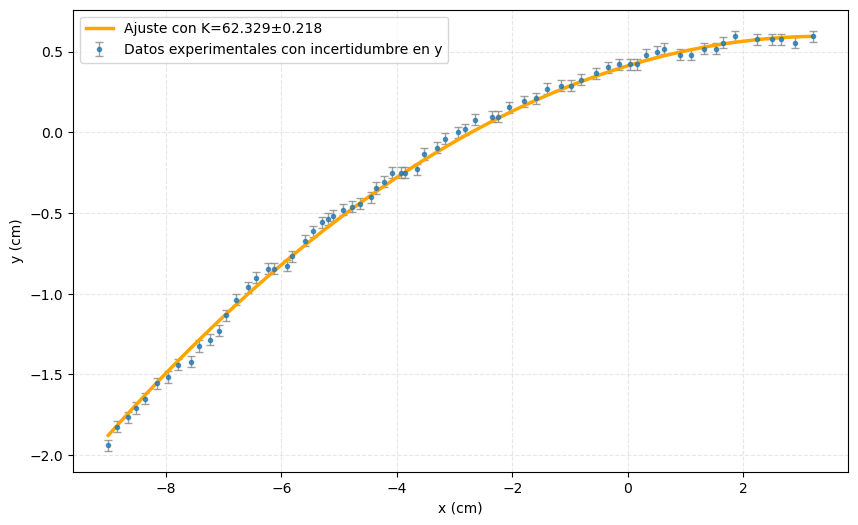

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

##################################################################################################################
########################################## Cambia este archivo si quieres ajustar otra experiencia ###############
##################################################################################################################

datos = '7_unlado.txt'


#  ---------------- Función para cargar datos desde el archivo de texto ----------------

def cargar_datos(ruta_txt):
    df = pd.read_csv(ruta_txt, sep='\t', decimal=',', skiprows=1, names=['t', 'x', 'y'])
    x = df['x'].to_numpy(dtype=float)
    y = df['y'].to_numpy(dtype=float)
    x0 = float(x[0])
    y0 = float(y[0])
    return x0, y0, x[1:], y[1:]

#función para calcular la rama y para el valor de x, dado el valor de K, x0 y y0, despejando y ((0.5*y0 - K)*(x-x0) - 0.5*x0*(y-y0))**2 = K**2*(0.5*y0 - K)*(y-y0)
#Existen dos ramas posibles para y, pero solo una de ellas es válida, pues solo una de ellas pasa por
#el punto inicial (x0, y0)

def y_ramas_para_x(x, K, x0, y0):
    # Calculamos únicamente la rama física (signo -) que corresponde a y2
    A = 0.5 * y0 - K
    dx = x - x0

    # Coeficiente cuadrático en dy: a = 0.25 * x0^2 (no usado explícitamente aquí)
    a = 0.25 * x0**2

    b = x0 * dx + K**2
    discriminante = b**2 - (x0**2) * (dx**2)
    discriminante = max(discriminante, 0.0)
    c = np.sqrt(discriminante)

    factor = (2.0 * A) / (x0**2)
    dy2 = factor * (b - c)

    return y0 + dy2


# función para calcular el ssr que queremos minimizar, que tiene como imput el valor de K el cual se va a optimizar

def calculo_ssr(K, x_data, y_data, x0, y0):
    ssr = 0.0
    puntos_totales_validos = 0

    for xi, yi in zip(x_data, y_data):
        y2 = y_ramas_para_x(xi, K, x0, y0)
        e2 = (yi - y2) ** 2
        ssr += e2
        puntos_totales_validos += 1

    return ssr

# Función que recorre todos los datos experimentales y para cada x
# calcula  la predicción y2, luego guardo en y_pred y marco el punto x como
# valido

def predecir_mejor_rama(K, x_data, y_data, x0, y0):
    # Se usa únicamente la rama negativa
    y_pred = np.full_like(y_data, np.nan)
    valid = np.zeros_like(y_data, dtype=bool)

    for i, (xi, yi) in enumerate(zip(x_data, y_data)):
        y2 = y_ramas_para_x(xi, K, x0, y0)
        y_pred[i] = y2
        valid[i] = True

    return y_pred, valid

# Función para calcular estadísticos de ajuste

def calcular_estadisticos(y_obs, y_calc, n_params):
    res = y_obs - y_calc
    n = len(y_obs)  # número de puntos válidos

    # Suma de cuadrados residuales
    ss_res = float(np.sum(res**2))

    grados_de_libertad = max(n - n_params, 1)


    return {
        'n': n,
        'df_res': grados_de_libertad,
        'ss_res': ss_res,
        'res': res,
    }


x0, y0, x_data, y_data = cargar_datos(datos)


# Rango para buscar el valor de K que hace que los datos se ajusten lo mejor posible a los datos experimentales

K_max = 200.0
K_min = -200.0


# Busco el valor de K que minimiza la suma de residuos al cuadrado
res = minimize_scalar(
    lambda K: calculo_ssr(K, x_data, y_data, x0, y0),
    bounds=(K_min, K_max),
    method='bounded',
    options={'xatol': 1e-10},
)

# Una vez encontrado el K óptimo, calculo la rama y del ajuste
K_best = float(res.x)
y_pred_best, valid_mask = predecir_mejor_rama(K_best, x_data, y_data, x0, y0)


yv = y_data[valid_mask]
yh = y_pred_best[valid_mask]
st = calcular_estadisticos(yv, yh, n_params=1)

# ********************Incertidumbre de la coordenda  y imponiendo chi^2 reducida = 1************************


sigma_y = np.sqrt(st['ss_res'] / st['df_res']) if st['df_res'] > 0 else np.nan
chi2_red = st['ss_res'] / (st['df_res'] * sigma_y**2) if np.isfinite(sigma_y) and sigma_y > 0 else np.nan
# Chi cuadrado reducida usando error fijo en y igual a 1
sigma_y_unidad = 1.0
chi2_red_sigma1 = st['ss_res'] / (st['df_res'] * sigma_y_unidad**2) if st['df_res'] > 0 else np.nan
y_err = np.full_like(y_data, sigma_y, dtype=float)


############################## Cálculo de la incertidumbre de K ###################################

def sigma_K(predict_func, K0, x_data, y_data, *args, delta=None):

    funcion_pred = predict_func
    x_datos = x_data
    y_datos = y_data

    # elegir un paso razonable si no se especifica
    if delta is None:
        delta = max(1e-8, abs(K0) * 1e-6, 1e-8)

    # predicción central y máscara de puntos válidos
    y0_pred, mascara_valida = funcion_pred(K0, x_datos, y_datos, *args)
    if not np.any(mascara_valida):
        return np.nan, np.nan, np.array([]), mascara_valida

    # valores observados y predichos solo para puntos válidos
    y_v = y_datos[mascara_valida]
    y_h = y0_pred[mascara_valida]

    # predicciones en K+delta y K-delta para aproximar la derivada
    y_plus, _ = funcion_pred(K0 + delta, x_datos, y_datos, *args)
    y_minus, _ = funcion_pred(K0 - delta, x_datos, y_datos, *args)
    y_plus = y_plus[mascara_valida]
    y_minus = y_minus[mascara_valida]

    # Jacobiano numérico (derivada de cada predicción respecto a K)
    J = (y_plus - y_minus) / (2.0 * delta)

    # residuos y suma de cuadrados residuales
    residuos = y_v - y_h
    n = len(y_v)
    p = 1  # número de parámetros (K)
    ssr = float(np.sum(residuos**2))

    # estimador de la varianza del ruido en y
    s2 = ssr / (n - p) if n > p else np.nan

    # suma de cuadrados de las derivadas
    S = float(np.sum(J**2))

    # varianza aproximada de K y su desviación típica
    varK = s2 / S if S > 0 else np.nan
    sigmaK = np.sqrt(varK) if np.isfinite(varK) and varK >= 0 else np.nan

    return sigmaK, s2, J, mascara_valida


def calcular_incertidumbre_K(K_val, x_data, y_data, x0, y0, predic_func, datos):

    sigmaK, s2, J, valid = sigma_K(predic_func, K_val, x_data, y_data, x0, y0)

    return sigmaK

# Llamada a la función para el calculo de la incertidumbre de K

sigmaK = calcular_incertidumbre_K(K_best, x_data, y_data, x0, y0, predecir_mejor_rama, datos)
ax_valid = valid_mask


#****************************** Imprimo los resultados obtenidos*************************************

print(f"Archivo usado        = {datos}")
print(f"K optimo             = {K_best:.3f}±{sigmaK:.3f} (cm)")
print(f"Puntos validos       = {np.sum(valid_mask)}/{len(x_data)}")
print(f"sigma_y (chi2_red=1) = {sigma_y:.8f} cm")
print(f"chi2 reducida        = {chi2_red:.8f}")
print(f"chi2 reducida (sigma_y=1) = {chi2_red_sigma1:.8f}")


#################### Representación ####################

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(x_data,y_data,yerr=y_err,fmt='o',ms=3,alpha=0.75,color='#1f77b4',ecolor='gray',elinewidth=1,capsize=3,label='Datos experimentales con incertidumbre en y',)
ax.plot(x_data[valid_mask],y_pred_best[valid_mask],'-',lw=2.5,color='orange',label=f'Ajuste con K={K_best:.3f}±{sigmaK:.3f}')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.grid(True, ls='--', alpha=0.3)
ax.legend()
plt.show()